# Lithuanian macroeconomic indicator dashboard snapshot



In [1]:
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

country_code = globals().get('country_code', 'LT')

current_dir = Path.cwd()
search_roots = [current_dir, *current_dir.parents]
module_path = next(
    (
        p
        for p in search_roots
        if (p / "macro_indicator_core.py").exists() and (p / "macro_indicator_pipeline.py").exists()
    ),
    None,
)
if module_path is None:
    module_path = next((p for p in search_roots if (p / "macro_indicator_pipeline.py").exists()), None)
if module_path is None:
    raise FileNotFoundError("macro_indicator_pipeline.py not found in current or parent directories.")

if str(module_path.resolve()) not in sys.path:
    sys.path.insert(0, str(module_path.resolve()))

from macro_indicator_pipeline import (
    get_pipeline_root,
    load_indicator_plot_glossary,
    resolve_indicator_plot_glossary_path,
    run,
    stream_resolved_sources,
)

root = get_pipeline_root()
project_subdir = Path('bs2026_student_projects') / 'Arturas_Sotnicenko'
outdir = root / project_subdir / 'outputs'


In [2]:
results = run(country_code=country_code, outdir=str(outdir), include_analysis=True)

indicator_index = results['indicator_index']
coverage = results['coverage']
missing_queue = results['missing_queue']
series_registry = results['series_registry']
resolved_registry = results['resolved_registry']
normalized_df = results['normalized_df']
fetch_status = results['fetch_status']
chart_manifest = results['chart_manifest']
coverage_gaps = results['coverage_gaps']
acceptance_checks = results['acceptance_checks']

stream = stream_resolved_sources(country_code=country_code, coverage=coverage)
endpoint_status = stream['endpoint_status_df']


In [3]:
glossary_path = resolve_indicator_plot_glossary_path(
    root=root,
    current_dir=current_dir,
    project_subdir=str(project_subdir),
)
if glossary_path is not None:
    chart_type_glossary, indicator_glossary = load_indicator_plot_glossary(glossary_path)
else:
    chart_type_glossary, indicator_glossary = {}, {}

print(f'Country code: {country_code}')
print(f'Output directory: {outdir.resolve()}')
if glossary_path is not None:
    print(f'Glossary loaded: {glossary_path}')
else:
    print('Glossary loaded: none (INDICATOR_PLOT_GLOSSARY.md not found)')


Country code: LT
Output directory: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs
Glossary loaded: /workspaces/da-ai/INDICATOR_PLOT_GLOSSARY.md


In [4]:
print('Coverage status counts:')
display(coverage['status'].value_counts().rename_axis('status').reset_index(name='count'))

print('Resolved endpoints in coverage:')
# display(
#     coverage[coverage['status'] == 'resolved'][
#         ['indicator_id', 'source_id', 'series_label', 'mapping_quality', 'resolved_url']
#     ].sort_values(['indicator_id', 'source_id'])
# )

print('Resolved registry diagnostics:')
display(
    resolved_registry[
        [
            'indicator_id',
            'source_id',
            'endpoint_status',
            'resolution_reason',
            'http_status',
            'resolved_url',
        ]
    ].sort_values(['indicator_id', 'source_id'])
)


Coverage status counts:


,status,count
0,missing_source,29
1,resolved,26
2,known_but_missing_params,15


Resolved endpoints in coverage:
Resolved registry diagnostics:


,indicator_id,source_id,endpoint_status,resolution_reason,http_status,resolved_url
0,exchange_rate_lcu_per_usd,eurostat,resolved,ok,200,https://ec.europa.eu/eurostat/api/disseminatio...
1,exchange_rate_lcu_per_usd,oecd,resolved,ok,200,https://sdmx.oecd.org/public/rest/data/DSD_EO@...
2,exchange_rate_lcu_per_usd,world_bank,resolved,ok,200,https://api.worldbank.org/v2/country/LT/indica...
3,gdp_current_usd,eurostat,resolved,ok,200,https://ec.europa.eu/eurostat/api/disseminatio...
4,gdp_current_usd,imf,resolved,ok,200,https://www.imf.org/external/datamapper/api/v1...
5,gdp_current_usd,oecd,resolved,ok,200,https://sdmx.oecd.org/public/rest/data/DSD_EO@...
6,gdp_current_usd,world_bank,resolved,ok,200,https://api.worldbank.org/v2/country/LT/indica...
7,gdp_per_capita,eurostat,resolved,ok,200,https://ec.europa.eu/eurostat/api/disseminatio...
8,gdp_per_capita,imf,resolved,ok,200,https://www.imf.org/external/datamapper/api/v1...
9,gdp_per_capita,world_bank,resolved,ok,200,https://api.worldbank.org/v2/country/LT/indica...


In [5]:
print('Mapping quality summary:')
# display(
#     series_registry.groupby(['indicator_id', 'mapping_quality'])
#     .size()
#     .rename('count')
#     .reset_index()
#     .sort_values(['indicator_id', 'mapping_quality'])
# )

print('Fetch status:')
# display(fetch_status.sort_values(['indicator_id', 'source_id']))

print('Coverage gaps and proxy caveats:')
# display(coverage_gaps.sort_values(['indicator_id', 'source_id', 'gap_type']))


Mapping quality summary:
Fetch status:
Coverage gaps and proxy caveats:


In [6]:
print('Normalized indicator dataset (head):')
# display(normalized_df.head(20))

print('Plot-ready source count by indicator:')
# display(
#     normalized_df.groupby('indicator_id')['source_id']
#     .nunique()
#     .rename('plot_ready_sources')
#     .reset_index()
#     .sort_values('indicator_id')
# )

print('Acceptance checks:')
# display(acceptance_checks)


Normalized indicator dataset (head):
Plot-ready source count by indicator:
Acceptance checks:


In [7]:
indicator_groups = {
    'Output and growth': [
        'gdp_current_usd',
        'gdp_per_capita',
    ],
    'Labor market': [
        'unemployment_rate',
    ],
    'Inflation and prices': [
        'inflation_cpi_yoy',
    ],
    'Monetary conditions and interest rates': [
        'lending_interest_rate',
    ],
    'Fiscal indicators': [],
    'External sector indicators': [
        'trade_balance_pct_gdp',
        'exchange_rate_lcu_per_usd',
    ],
    'Confidence and surveys': [],
}

available_ids = indicator_index['indicator_id'].tolist()
available_set = set(available_ids)
grouped_ids = []
print(available_ids)

['gdp_current_usd', 'gdp_per_capita', 'inflation_cpi_yoy', 'trade_balance_pct_gdp', 'lending_interest_rate', 'unemployment_rate', 'exchange_rate_lcu_per_usd']


In [8]:
def _render_indicator(indicator_id: str) -> None:
    display(Markdown(f'## {indicator_id}'))
    manifest_rows = chart_manifest[chart_manifest['indicator_id'] == indicator_id].sort_values('chart_type')
    display(manifest_rows[['chart_type', 'status', 'base_year', 'file_path', 'note']])

    indicator_glossary_shown = False
    for _, chart_row in manifest_rows.iterrows():
        if chart_row['status'] != 'ok':
            continue

        chart_type = str(chart_row['chart_type'])
        # display(Markdown(f"**{chart_type}**"))
        display(Image(filename=chart_row['file_path']))

        chart_note = chart_type_glossary.get(chart_type)
        if chart_note:
            display(Markdown(f"_Glossary:_ {chart_note}"))

        if not indicator_glossary_shown:
            indicator_note = indicator_glossary.get(indicator_id, '')
            if indicator_note:
                display(Markdown("**Indicator mapping glossary**\n\n" + indicator_note))
                indicator_glossary_shown = True


# Output and growth

## gdp_current_usd

,chart_type,status,base_year,file_path,note
5,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
3,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,Rendered in canonical USD so IMF NGDPD (billio...
4,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


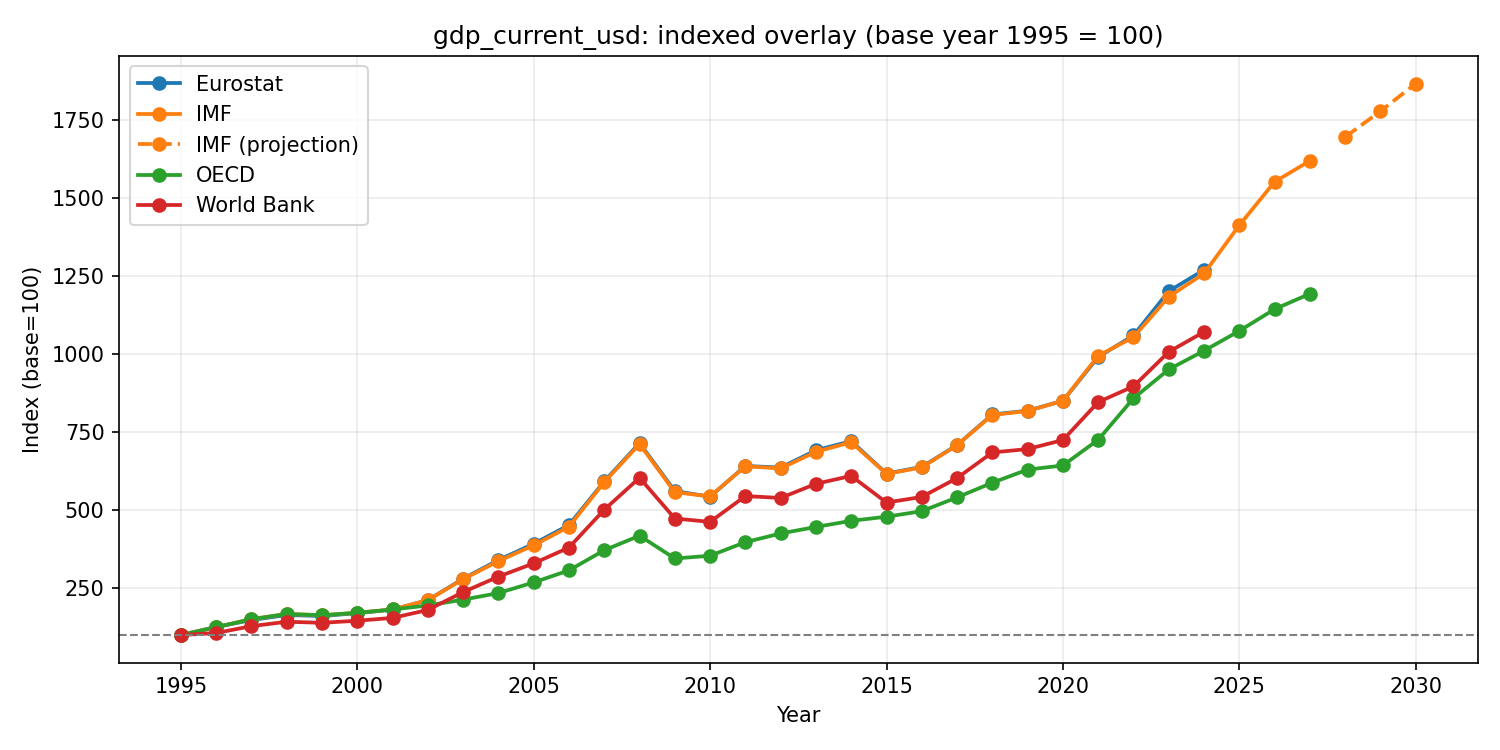

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.CD`) | `USD` | `USD` | `value_canonical = value_raw` | Exact mapping |
| IMF (`NGDPD`) | source-defined | `USD` | `value_canonical = value_raw * 1e9` | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_gdp`, `CP_MEUR`) | million EUR | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates (not WB current US$) |

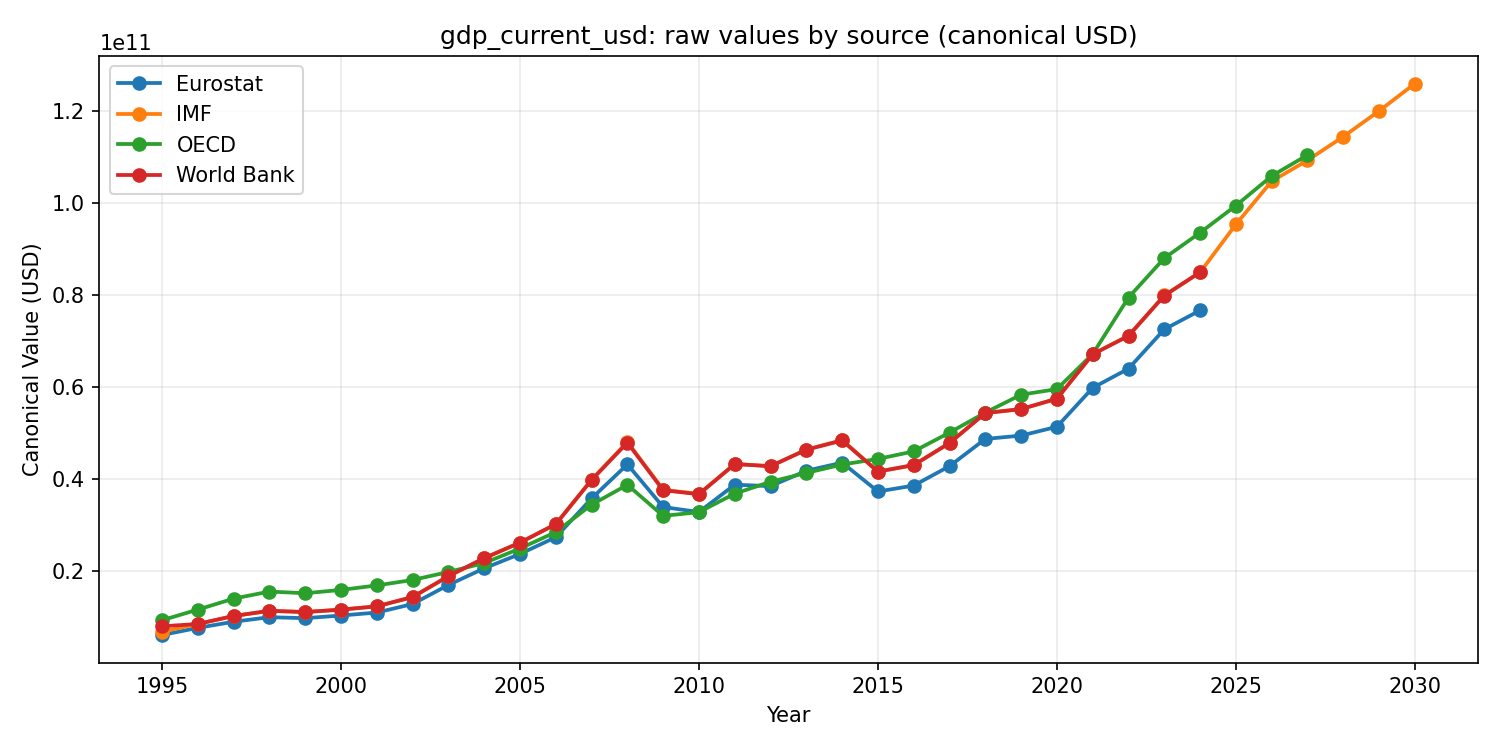

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

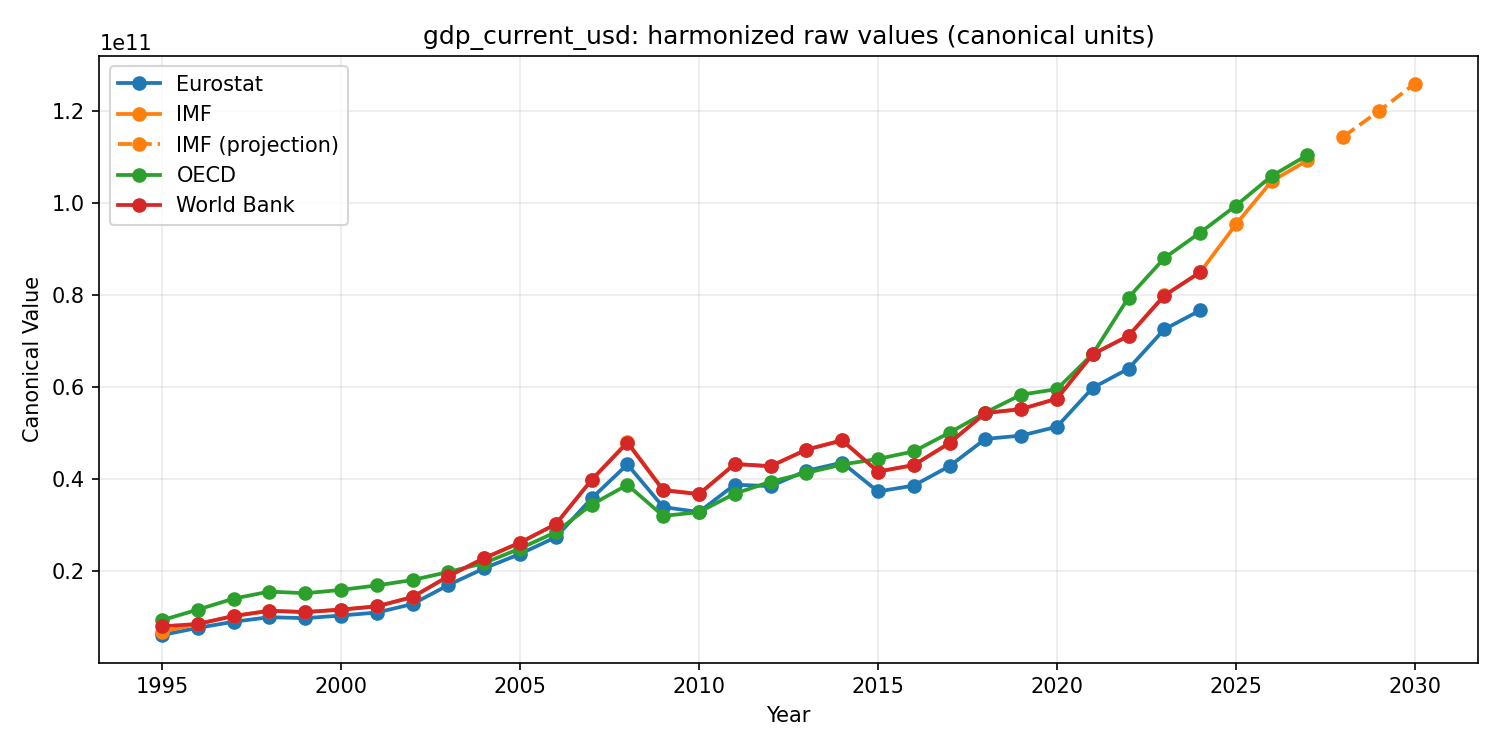

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## gdp_per_capita

,chart_type,status,base_year,file_path,note
8,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
6,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,Rendered in canonical USD per capita so Eurost...
7,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


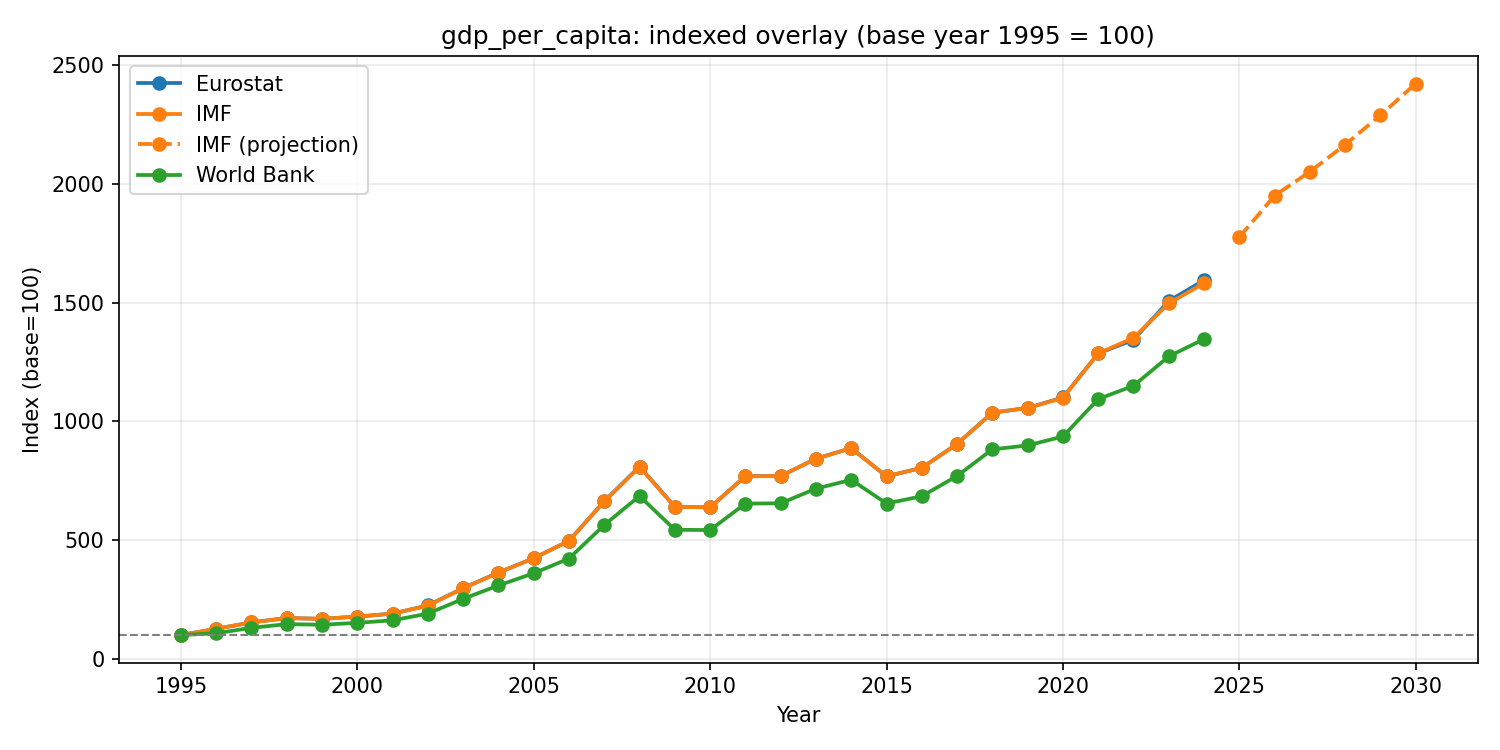

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.PCAP.CD`) | USD per capita | USD per capita | identity | Exact mapping |
| IMF (`NGDPDPC`) | source-defined | USD per capita | identity | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_pc`, `CP_EUR_HAB`) | EUR per inhabitant | USD per capita | `value_canonical = value_raw * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |

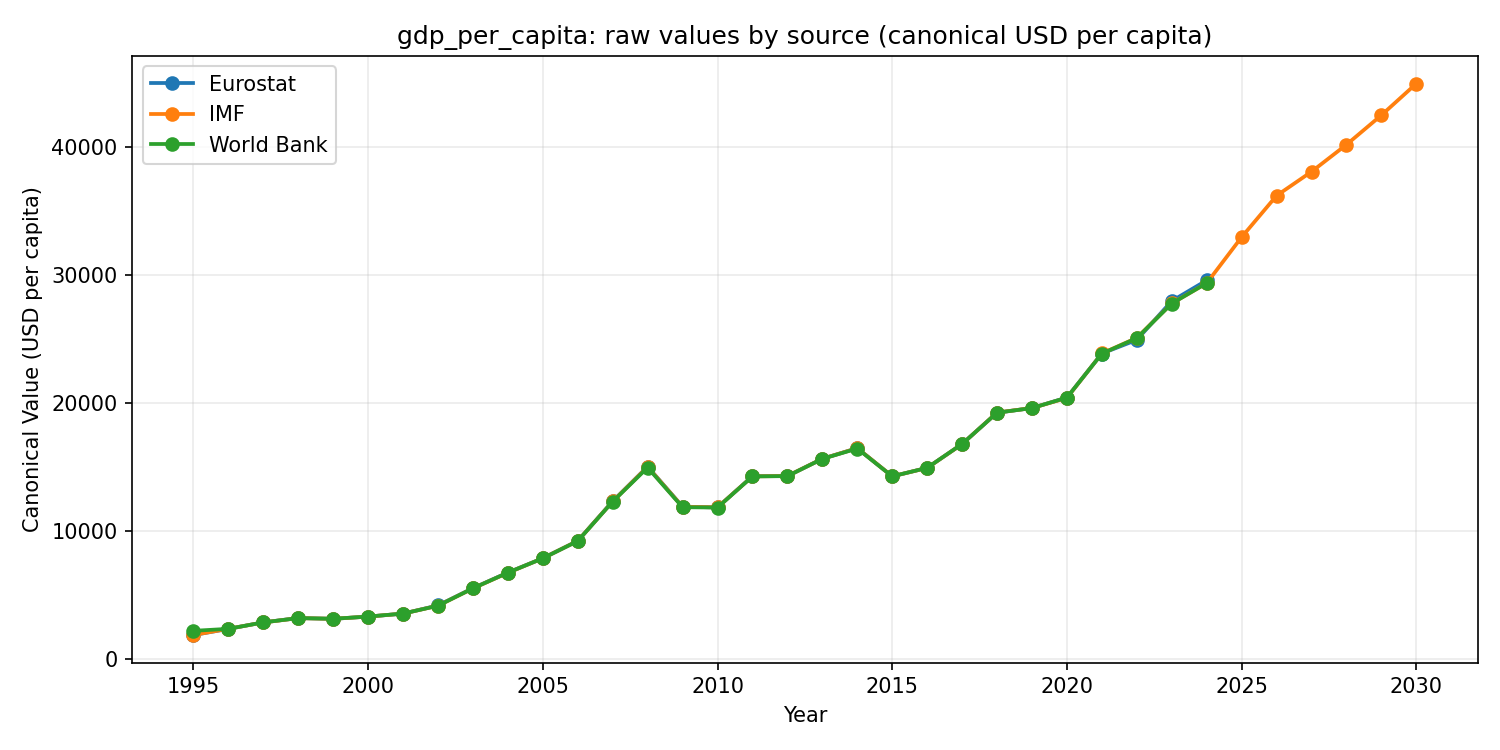

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

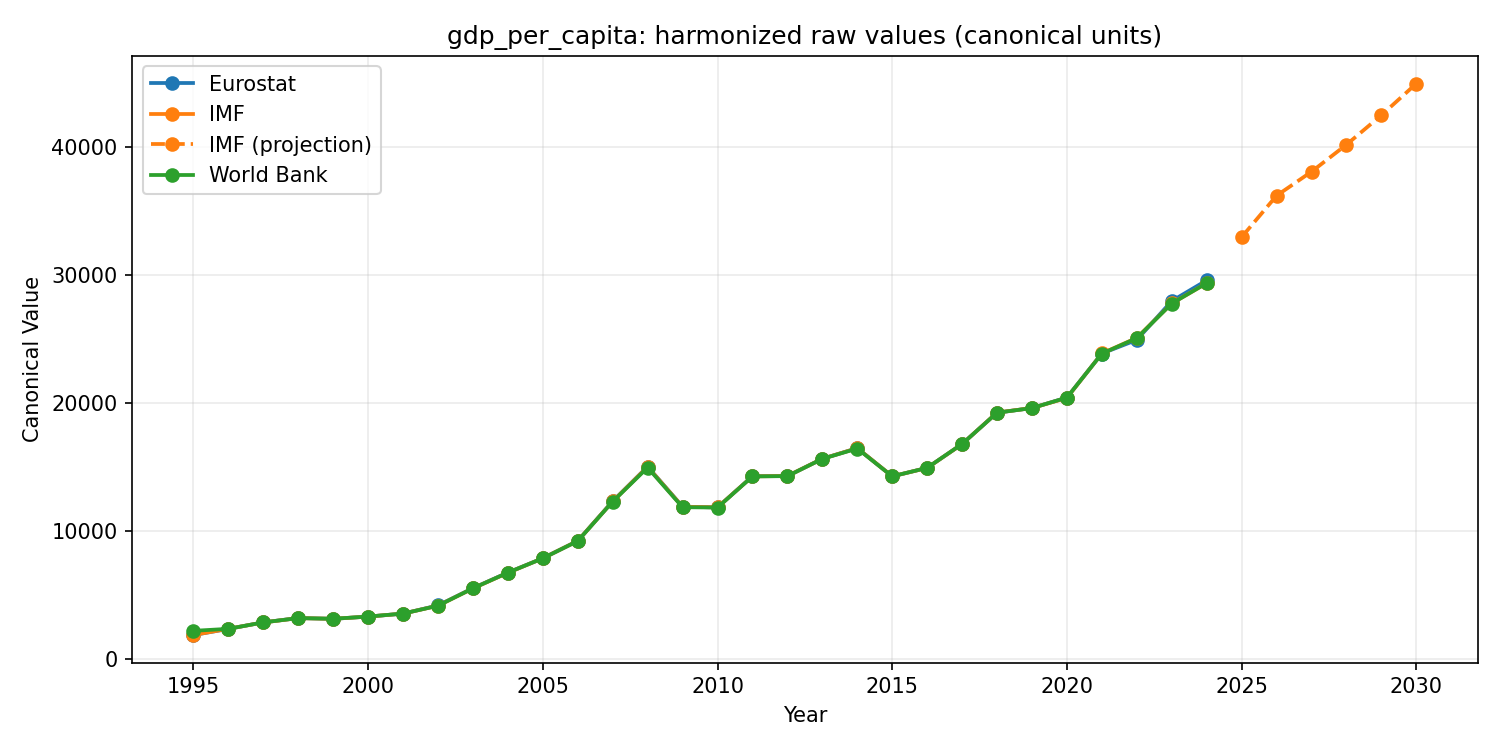

_Glossary:_ canonical-unit values for comparable cross-source analysis.

# Labor market

## unemployment_rate

,chart_type,status,base_year,file_path,note
20,overlay_index,ok,1999.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
18,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
19,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


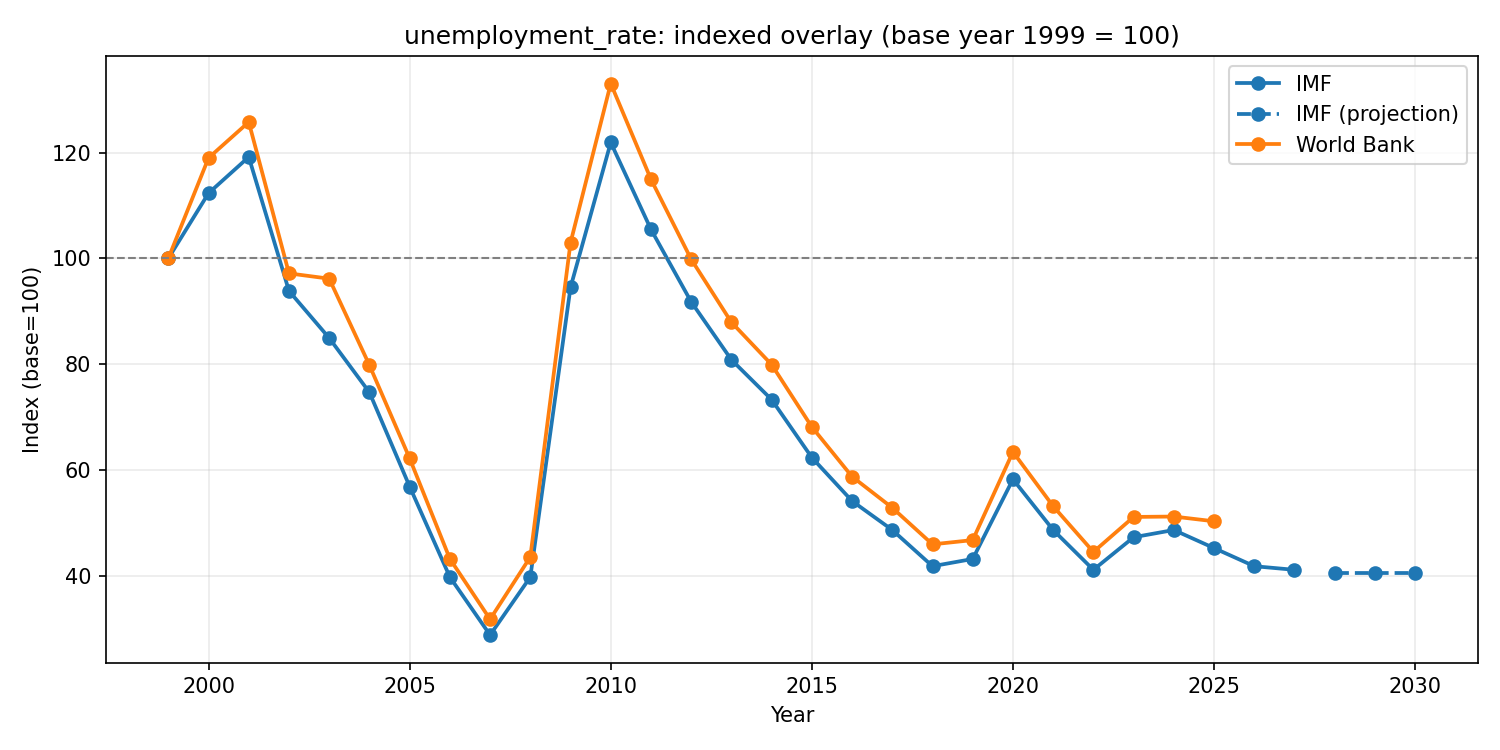

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`SL.UEM.TOTL.ZS`) | percent | percent | identity | Exact mapping |
| IMF (`LUR`) | source-defined | percent | identity | Comparable concept; possible projection years |
| Eurostat (`une_rt_a`) | `PC_ACT` | percent | identity | Proxy (methodology differences) |
| OECD (`DSD_EO@DF_EO`, `UNR`) | percent | percent | identity | Comparable unemployment concept from OECD EO |

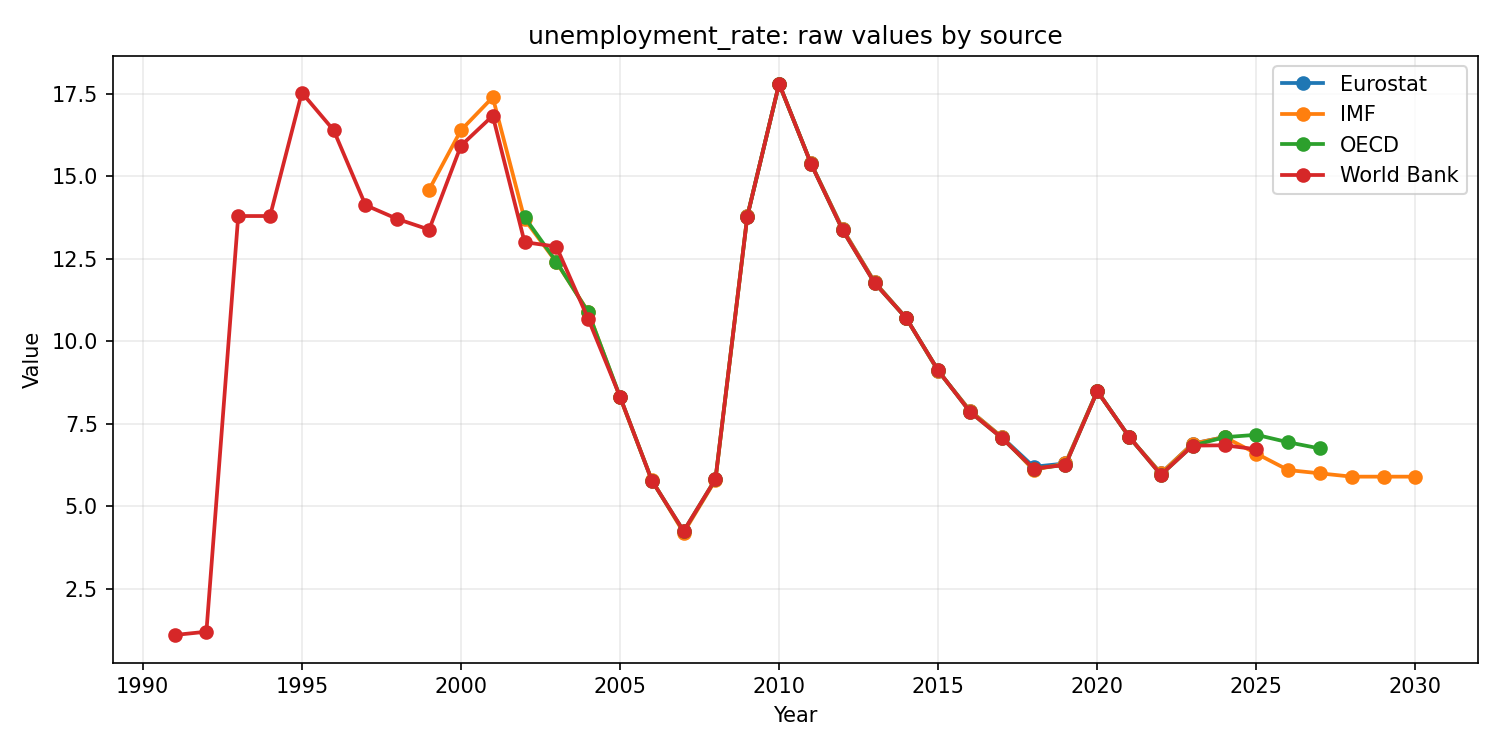

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

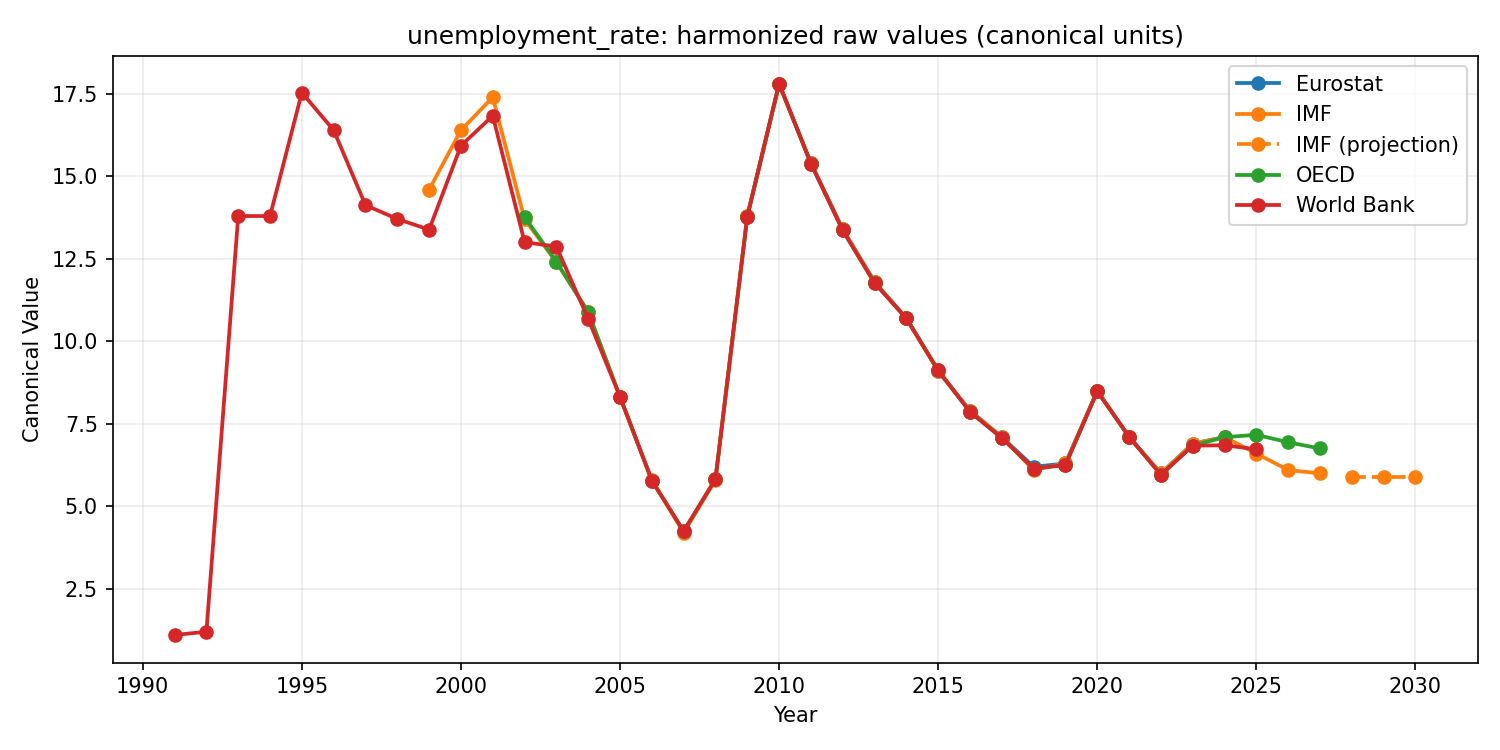

_Glossary:_ canonical-unit values for comparable cross-source analysis.

# Inflation and prices

## inflation_cpi_yoy

,chart_type,status,base_year,file_path,note
11,overlay_index,ok,1996.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
9,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
10,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


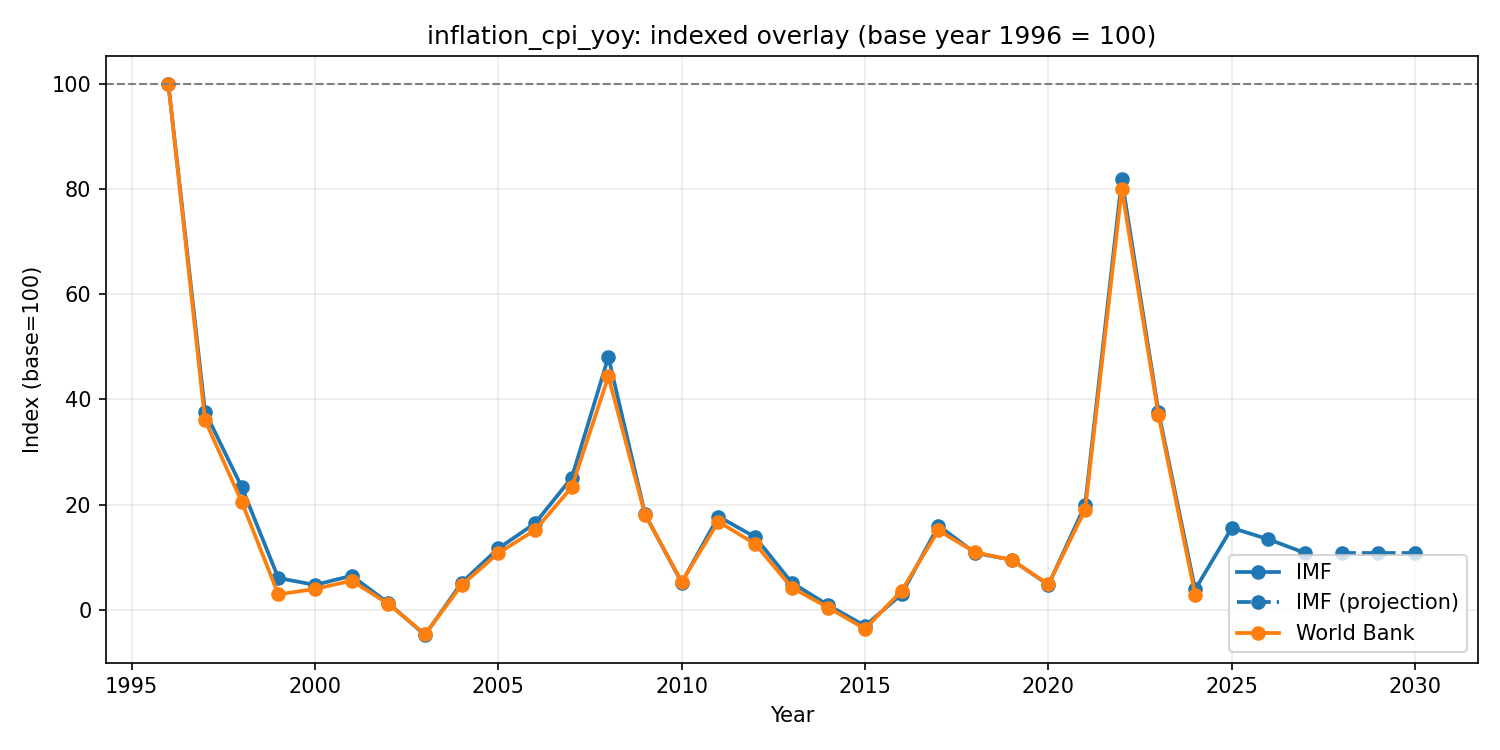

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FP.CPI.TOTL.ZG`) | percent | percent | identity | Exact mapping |
| IMF (`PCPIPCH`) | source-defined | percent | identity | Proxy-equivalent concept; future years can be projections |
| Eurostat (`prc_hicp_manr`) | `RCH_A` monthly YoY | percent annual | annual mean of monthly values | Proxy with methodology differences |
| OECD (`DSD_EO@DF_EO`, `CPIH_YTYPCT`) | percent | percent | identity | Proxy: harmonised CPI annual inflation rate |

Chart rendering note: `inflation_cpi_yoy` raw and raw-harmonized charts use a logarithmic y-axis; if any non-positive values exist, the axis falls back to `symlog`.

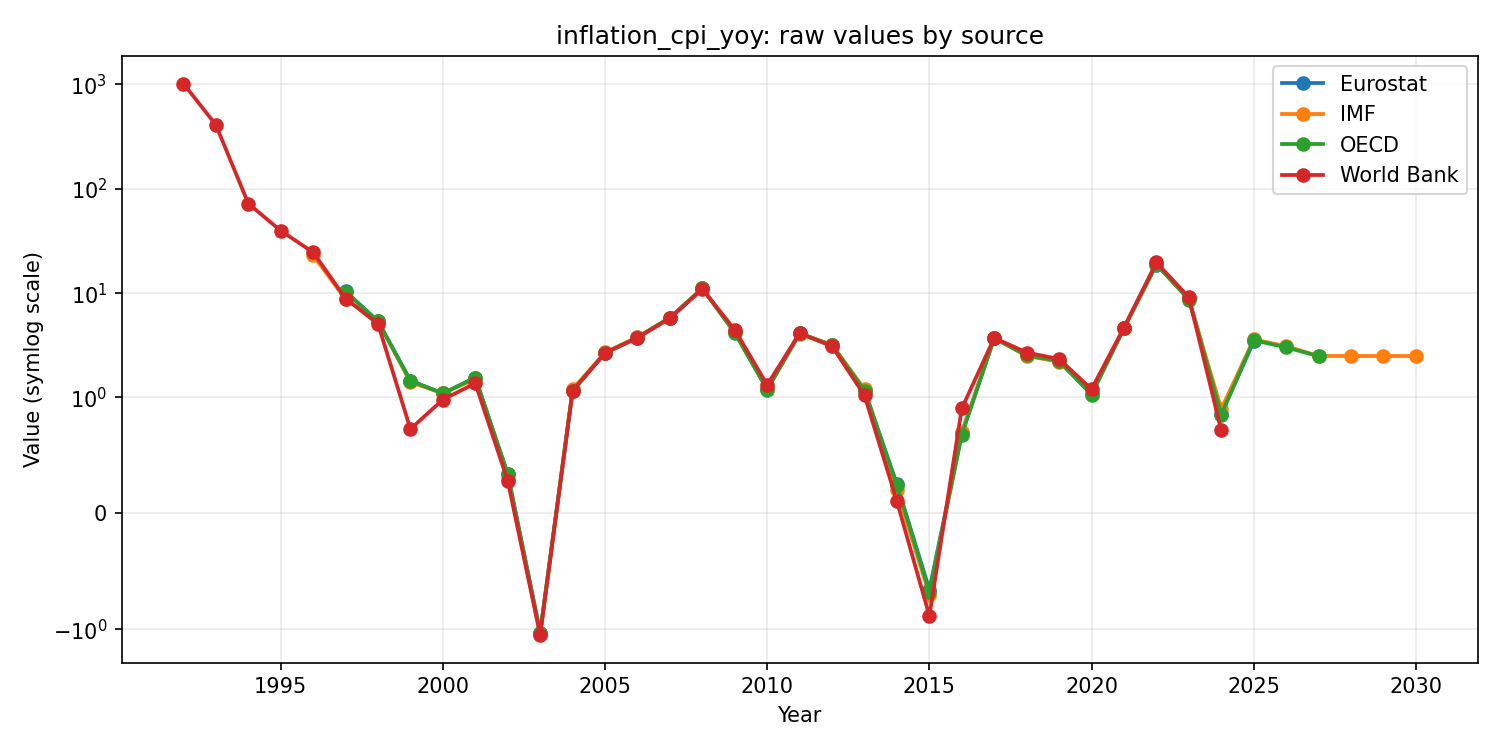

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

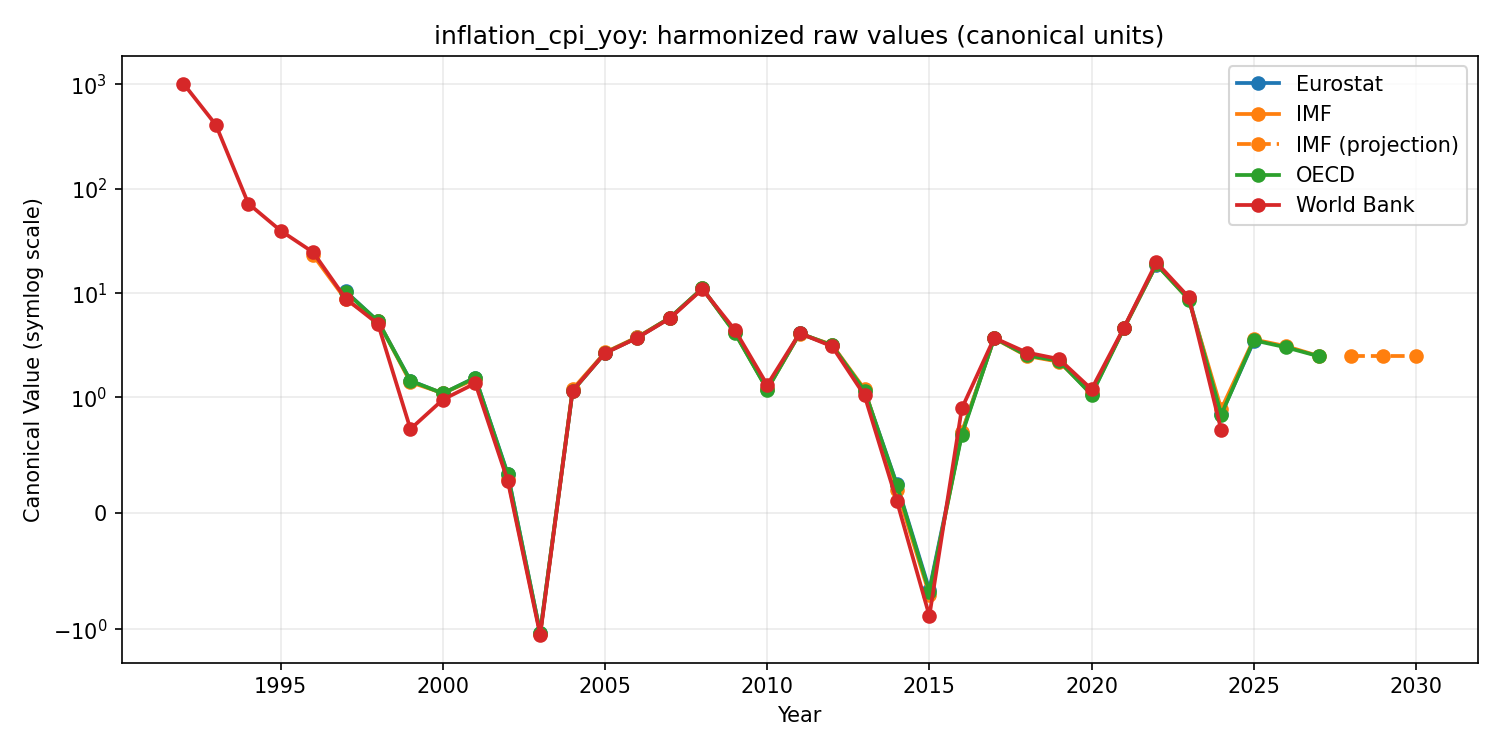

_Glossary:_ canonical-unit values for comparable cross-source analysis.

# Monetary conditions and interest rates

## lending_interest_rate

,chart_type,status,base_year,file_path,note
14,overlay_index,ok,2000.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
12,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
13,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


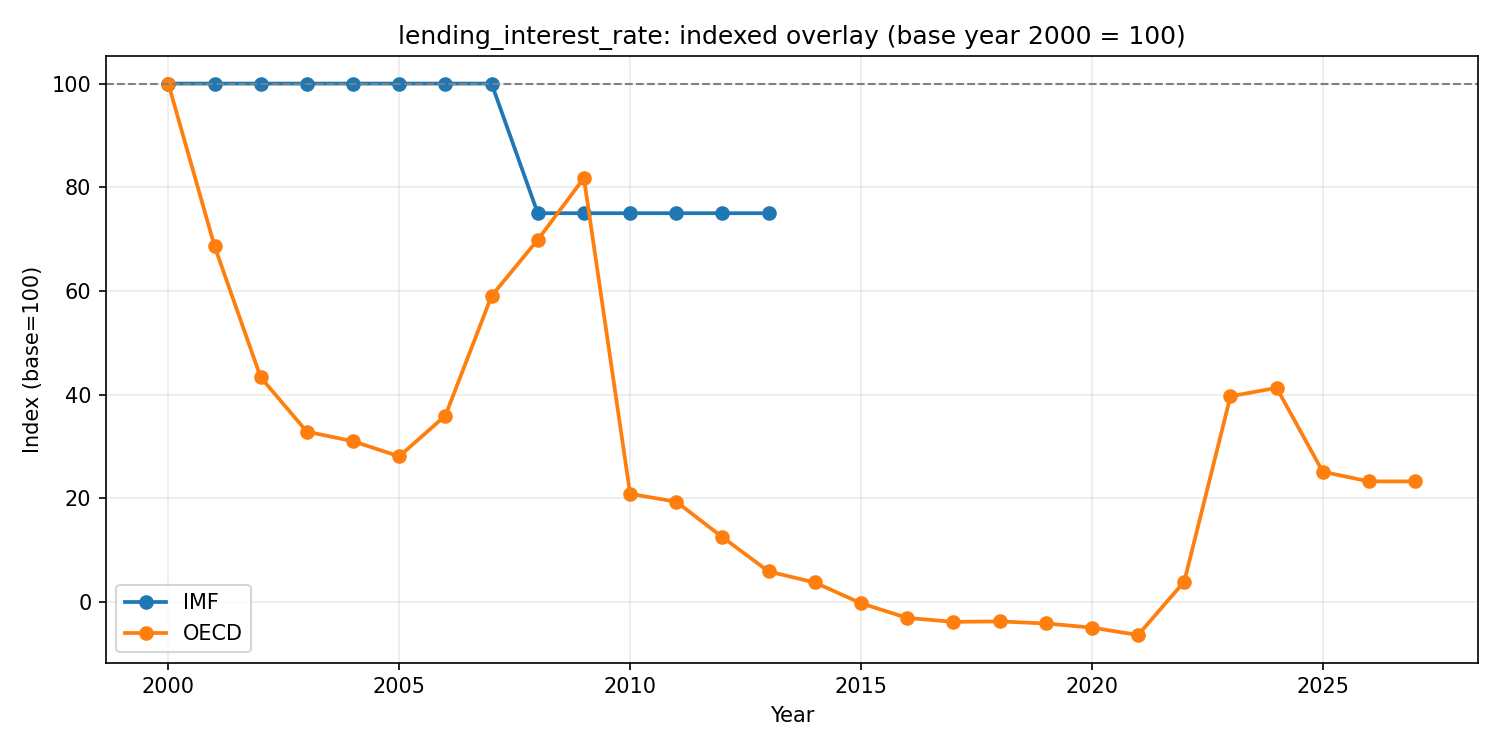

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FR.INR.LEND`) | percent | percent | identity | Endpoint resolves but currently no numeric LT rows |
| IMF (`Ka_mm`) | index | percent (pipeline canonical target) | identity | Weak proxy; LT availability only to 2013 |
| Eurostat (`irt_lt_mcby_a`) | percent | percent | identity | Proxy (long-term rate, not direct lending rate) |
| OECD (`DSD_EO@DF_EO`, `IRS`) | percent | percent | identity | Proxy: short-term interest rate, not direct lending rate |

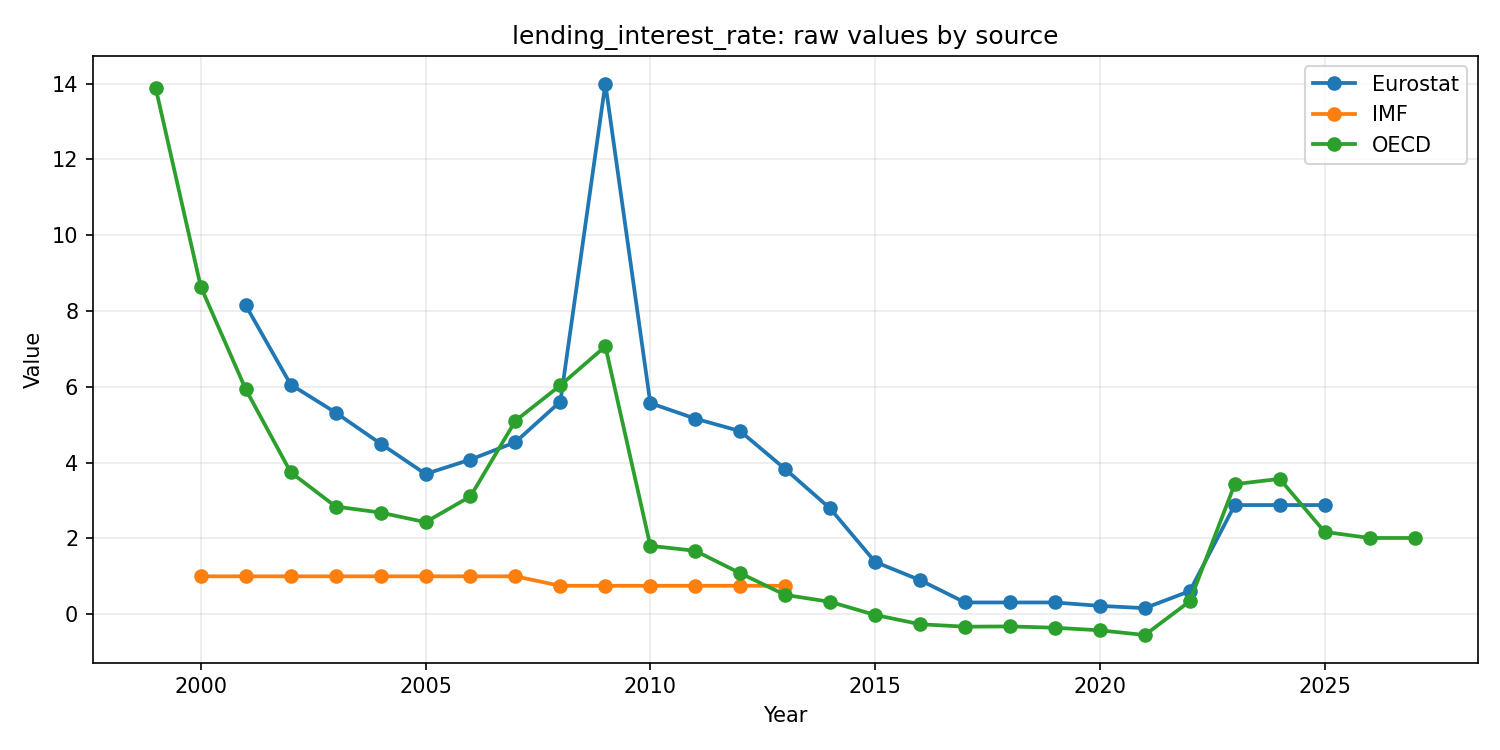

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

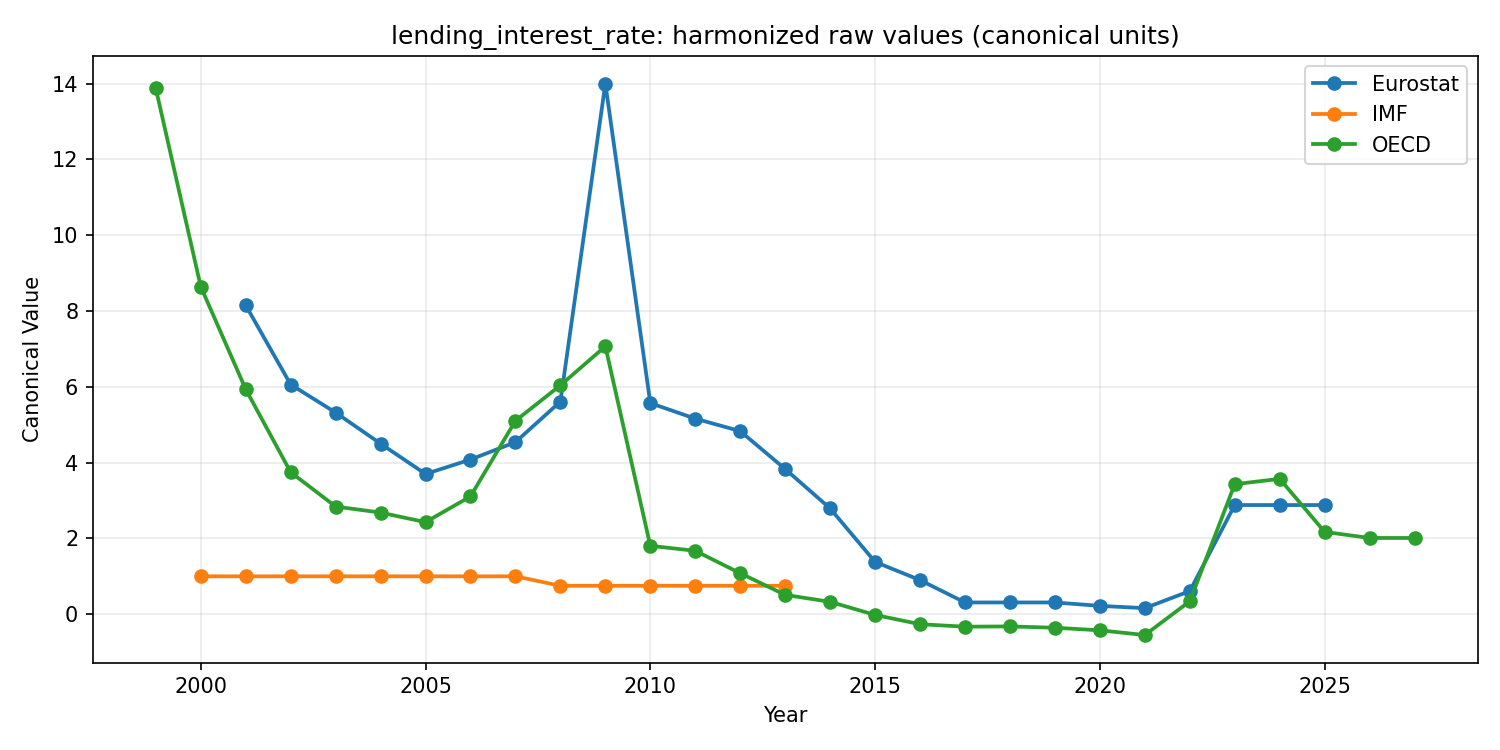

_Glossary:_ canonical-unit values for comparable cross-source analysis.

# Fiscal indicators

_No indicators mapped in current pipeline output._

# External sector indicators

## trade_balance_pct_gdp

,chart_type,status,base_year,file_path,note
17,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
15,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
16,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


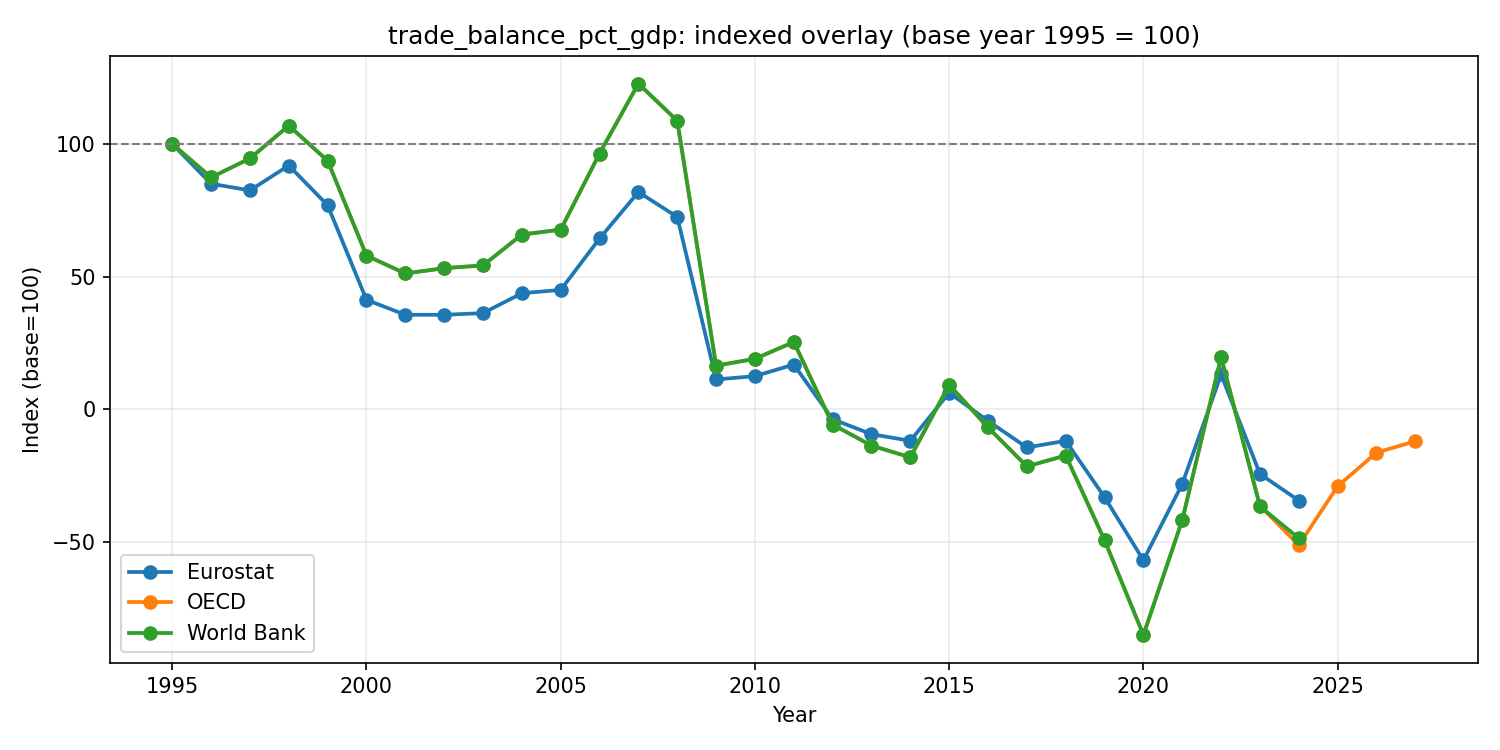

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NE.RSB.GNFS.ZS`) | percent of GDP | percent of GDP | identity | Exact mapping |
| IMF (`BT_GDP`) | source-defined | percent of GDP | identity | Proxy with potential definition differences |
| Eurostat (`bop_gdp6_q`) | `PC_GDP` | percent of GDP | identity | Proxy (BPM6 framing differs) |
| OECD (`DSD_EO@DF_EO`, `FBGSQ`) | percent of GDP | percent of GDP | identity | Proxy: net exports of goods/services as % GDP |

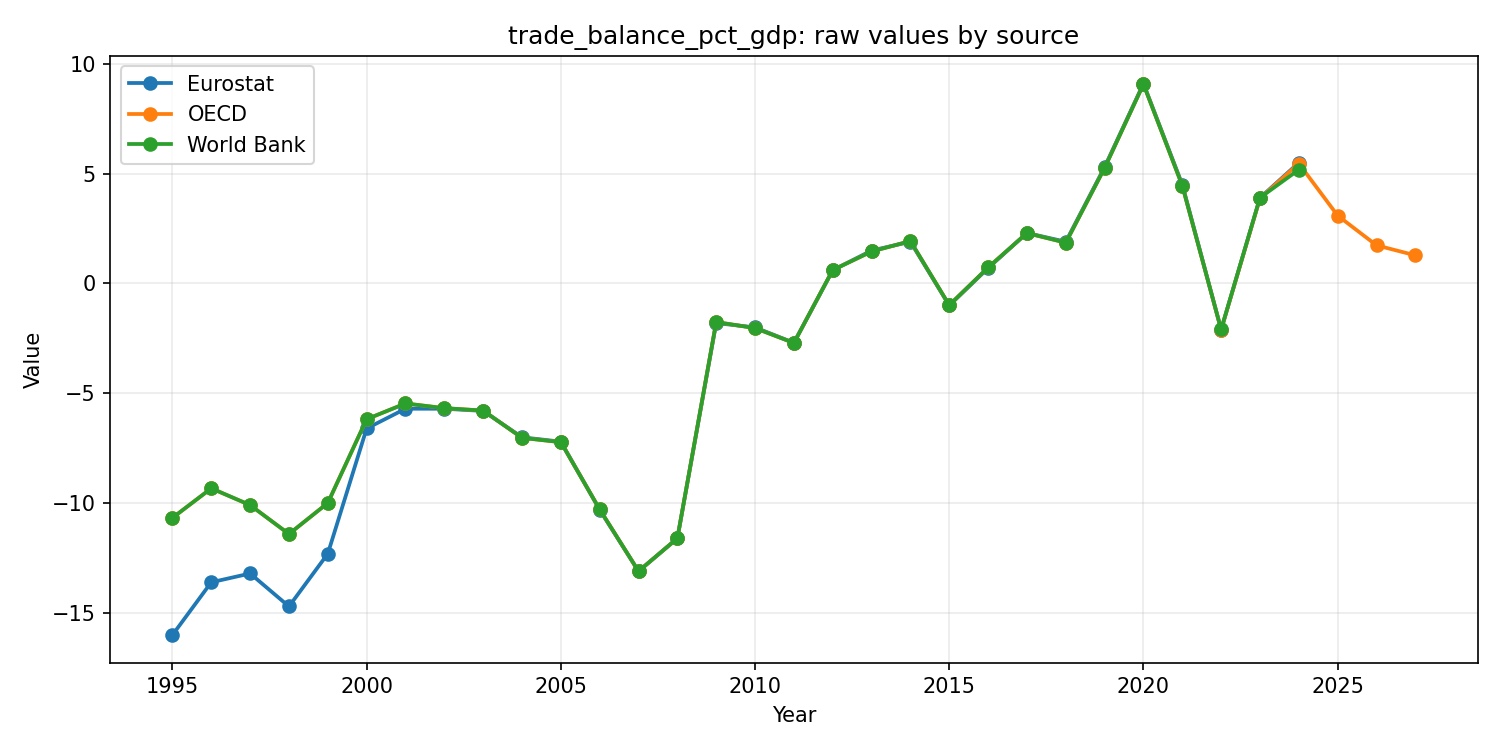

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

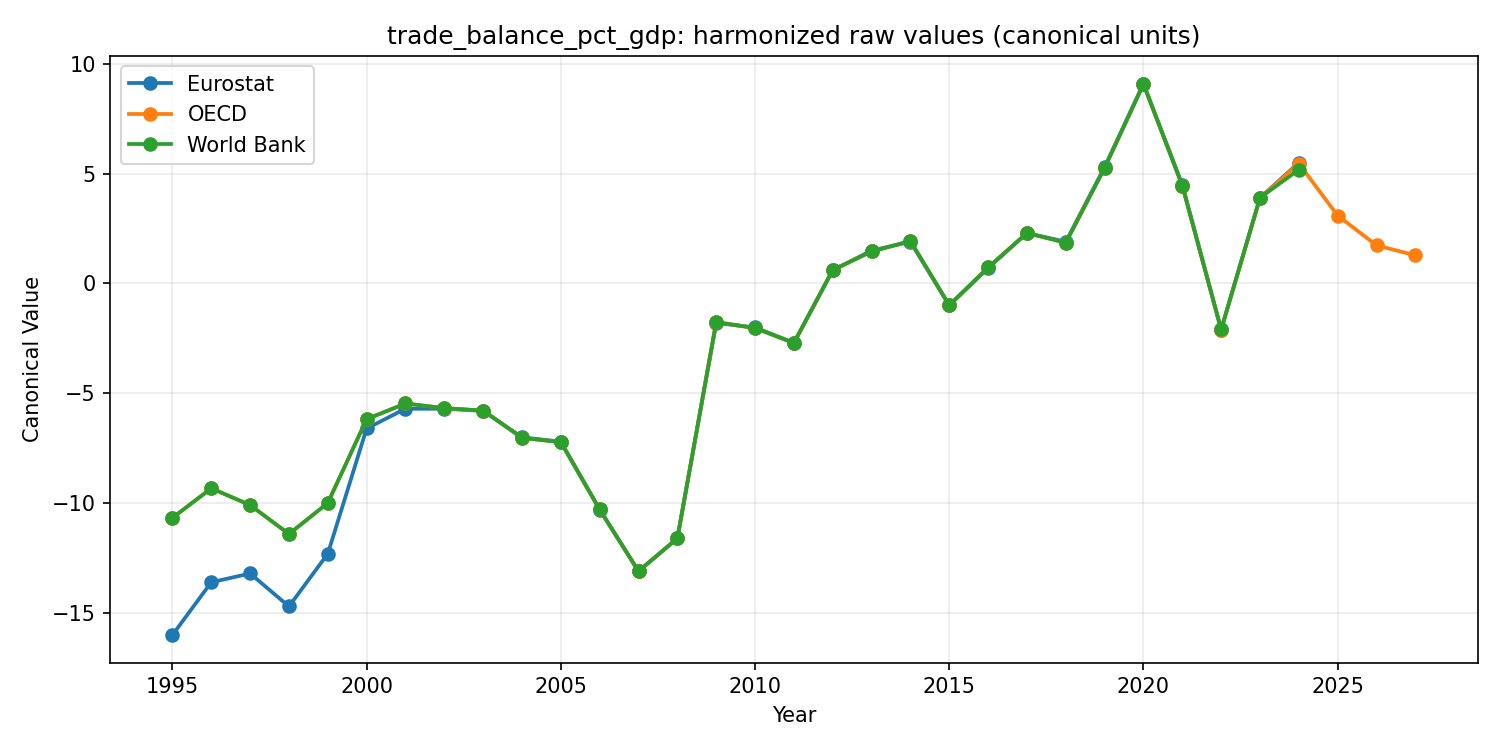

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## exchange_rate_lcu_per_usd

,chart_type,status,base_year,file_path,note
2,overlay_index,ok,1994.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
0,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


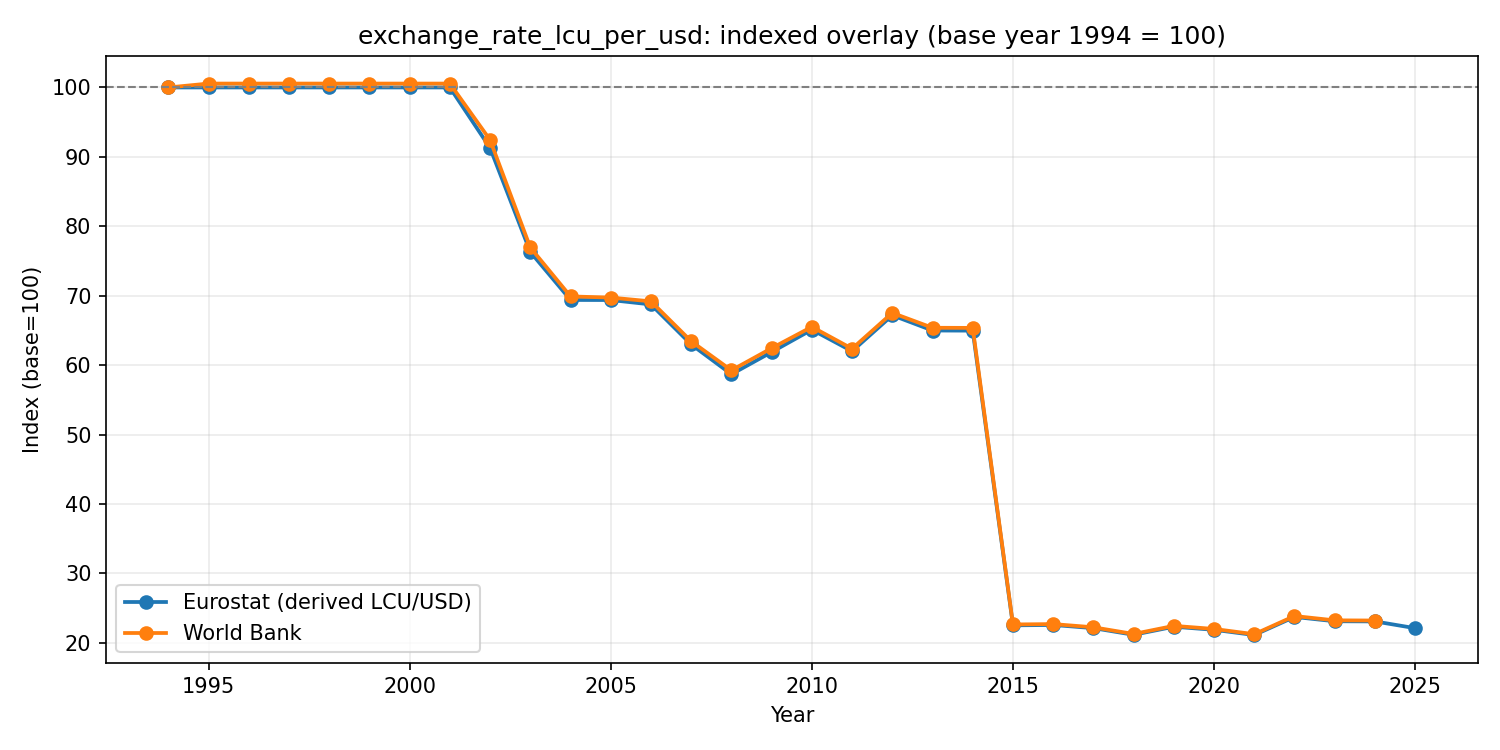

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`PA.NUS.FCRF`) | LCU per USD | LCU per USD | identity | Exact mapping |
| Eurostat raw (`ert_bil_eur_a`) | USD per EUR (`NAC`) | LCU per USD target | not directly comparable | Marked `is_comparable=false` for cross-source overlays |
| Eurostat derived (`eurostat_derived`) | derived from USD/EUR | LCU per USD | LT regime rules by year | Comparable series used in harmonized/overlay charts |
| OECD (`DSD_EO@DF_EO`, `EXCHUD`) | LCU per USD | LCU per USD | identity | Proxy: OECD EO exchange-rate conventions can differ by historical treatment |

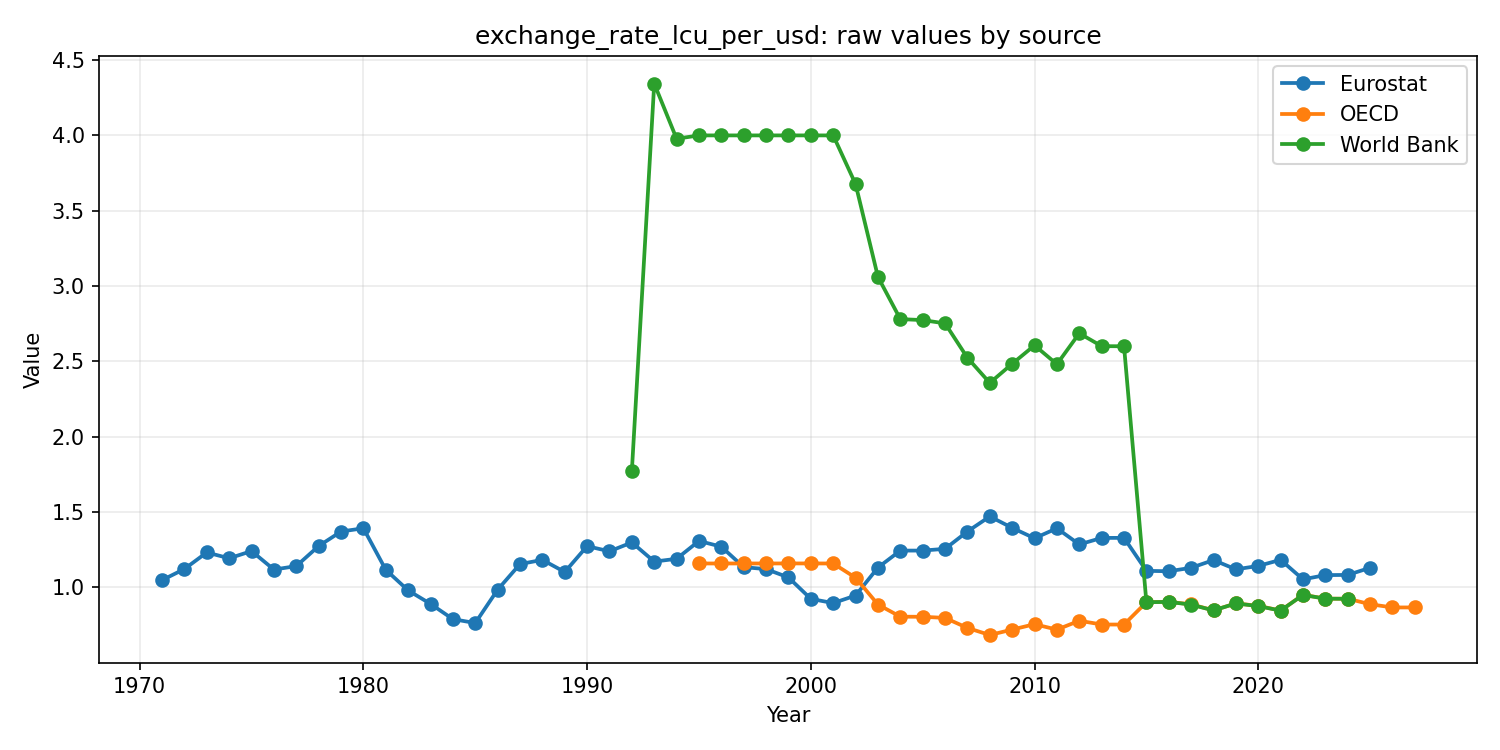

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` and `gdp_per_capita` which are rendered in canonical USD units to avoid mixed-scale flattening.

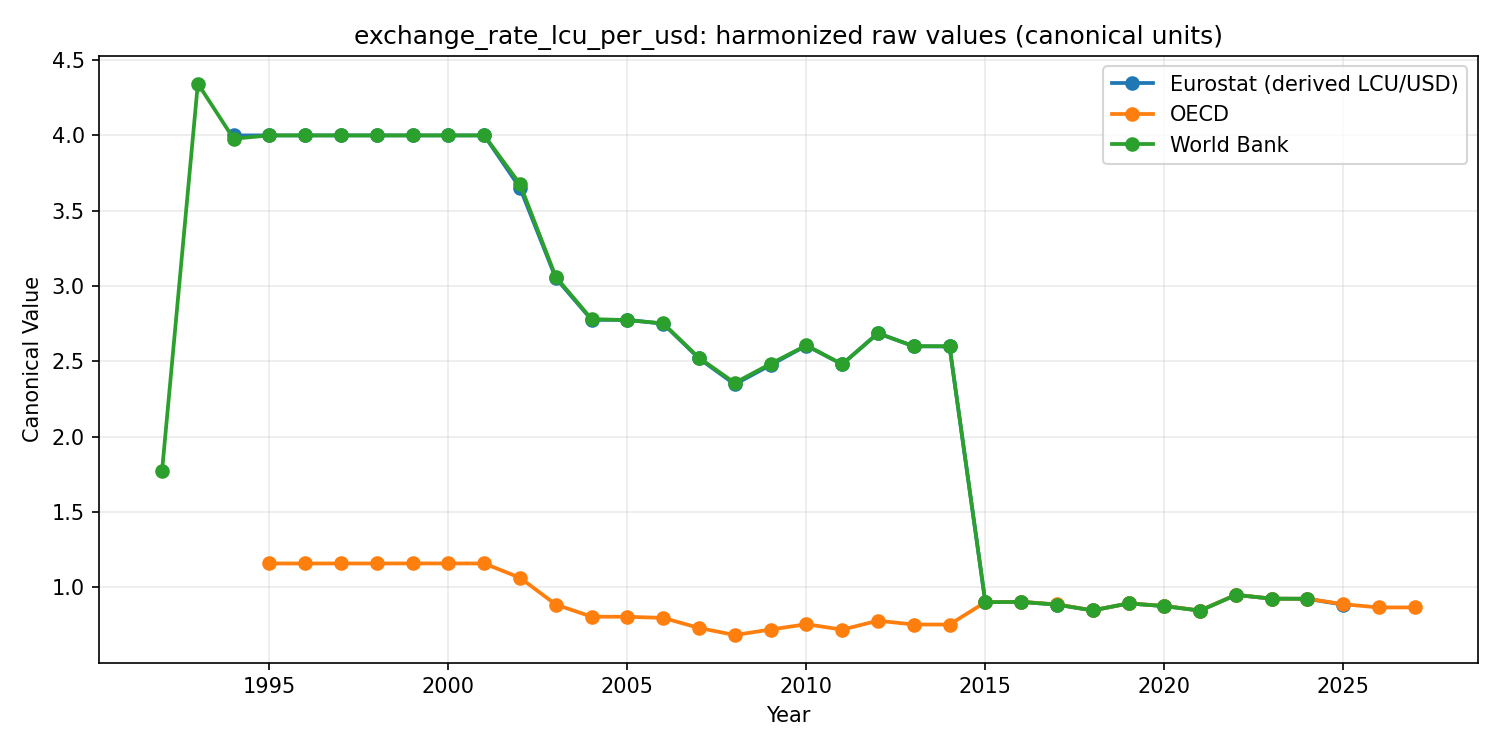

_Glossary:_ canonical-unit values for comparable cross-source analysis.

# Confidence and surveys

_No indicators mapped in current pipeline output._

In [9]:
for group_name, indicator_ids in indicator_groups.items():
    display(Markdown(f'# {group_name}'))
    present_ids = [indicator_id for indicator_id in indicator_ids if indicator_id in available_set]

    if not present_ids:
        display(Markdown('_No indicators mapped in current pipeline output._'))
        continue

    for indicator_id in present_ids:
        grouped_ids.append(indicator_id)
        _render_indicator(indicator_id)


In [10]:
remaining_ids = [indicator_id for indicator_id in available_ids if indicator_id not in set(grouped_ids)]
if remaining_ids:
    display(Markdown('# Other indicators'))
    for indicator_id in remaining_ids:
        _render_indicator(indicator_id)


# Static Z-score normalization


## Static z-score visuals

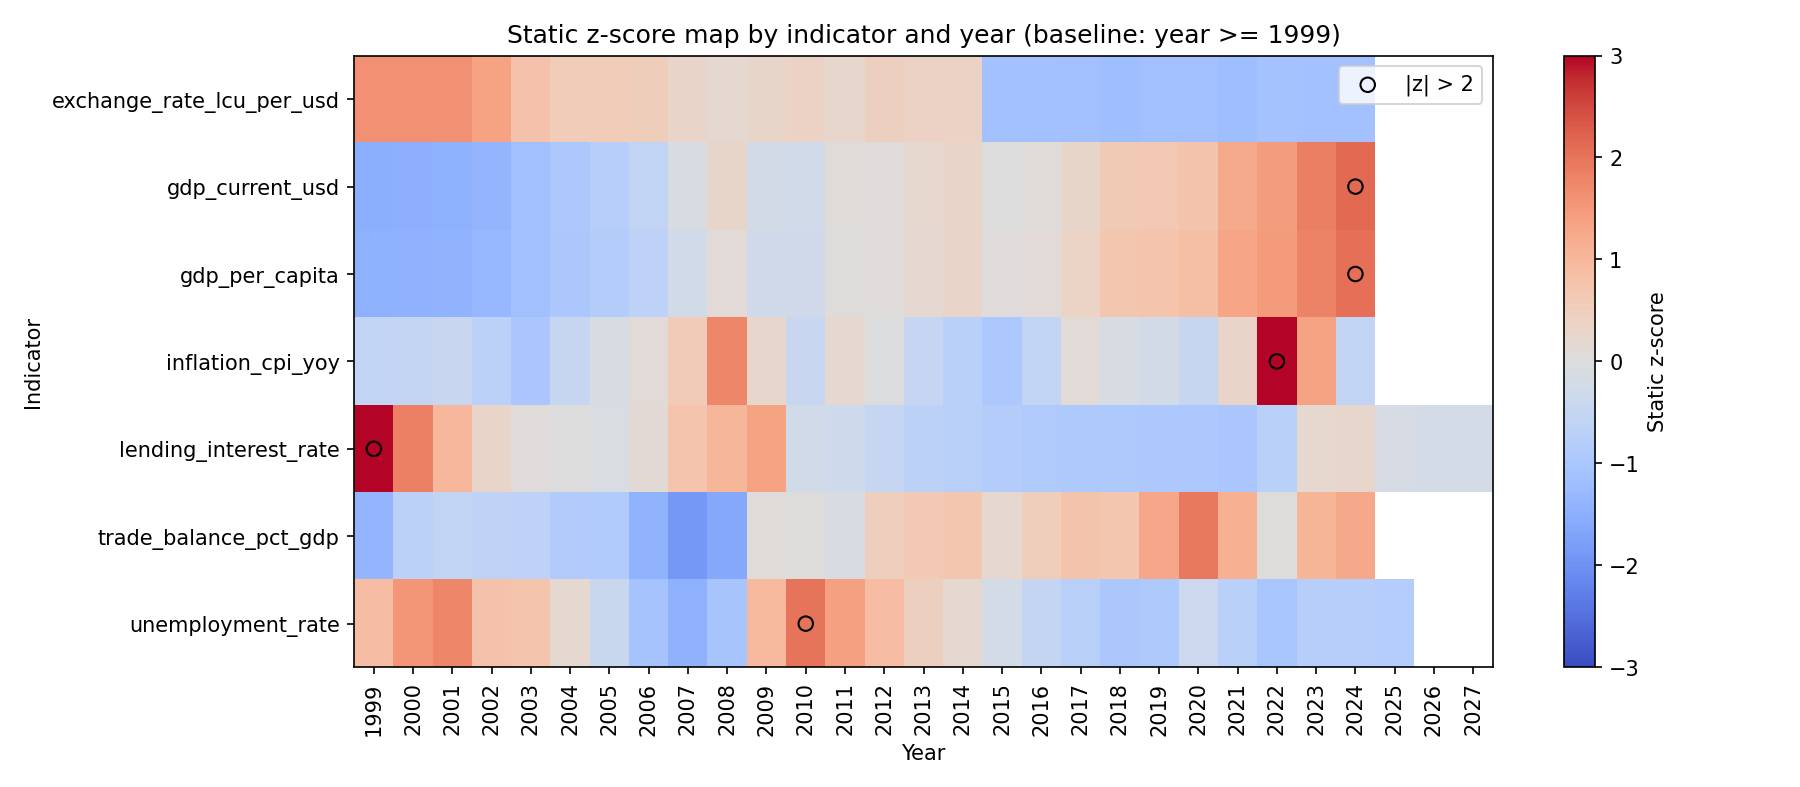

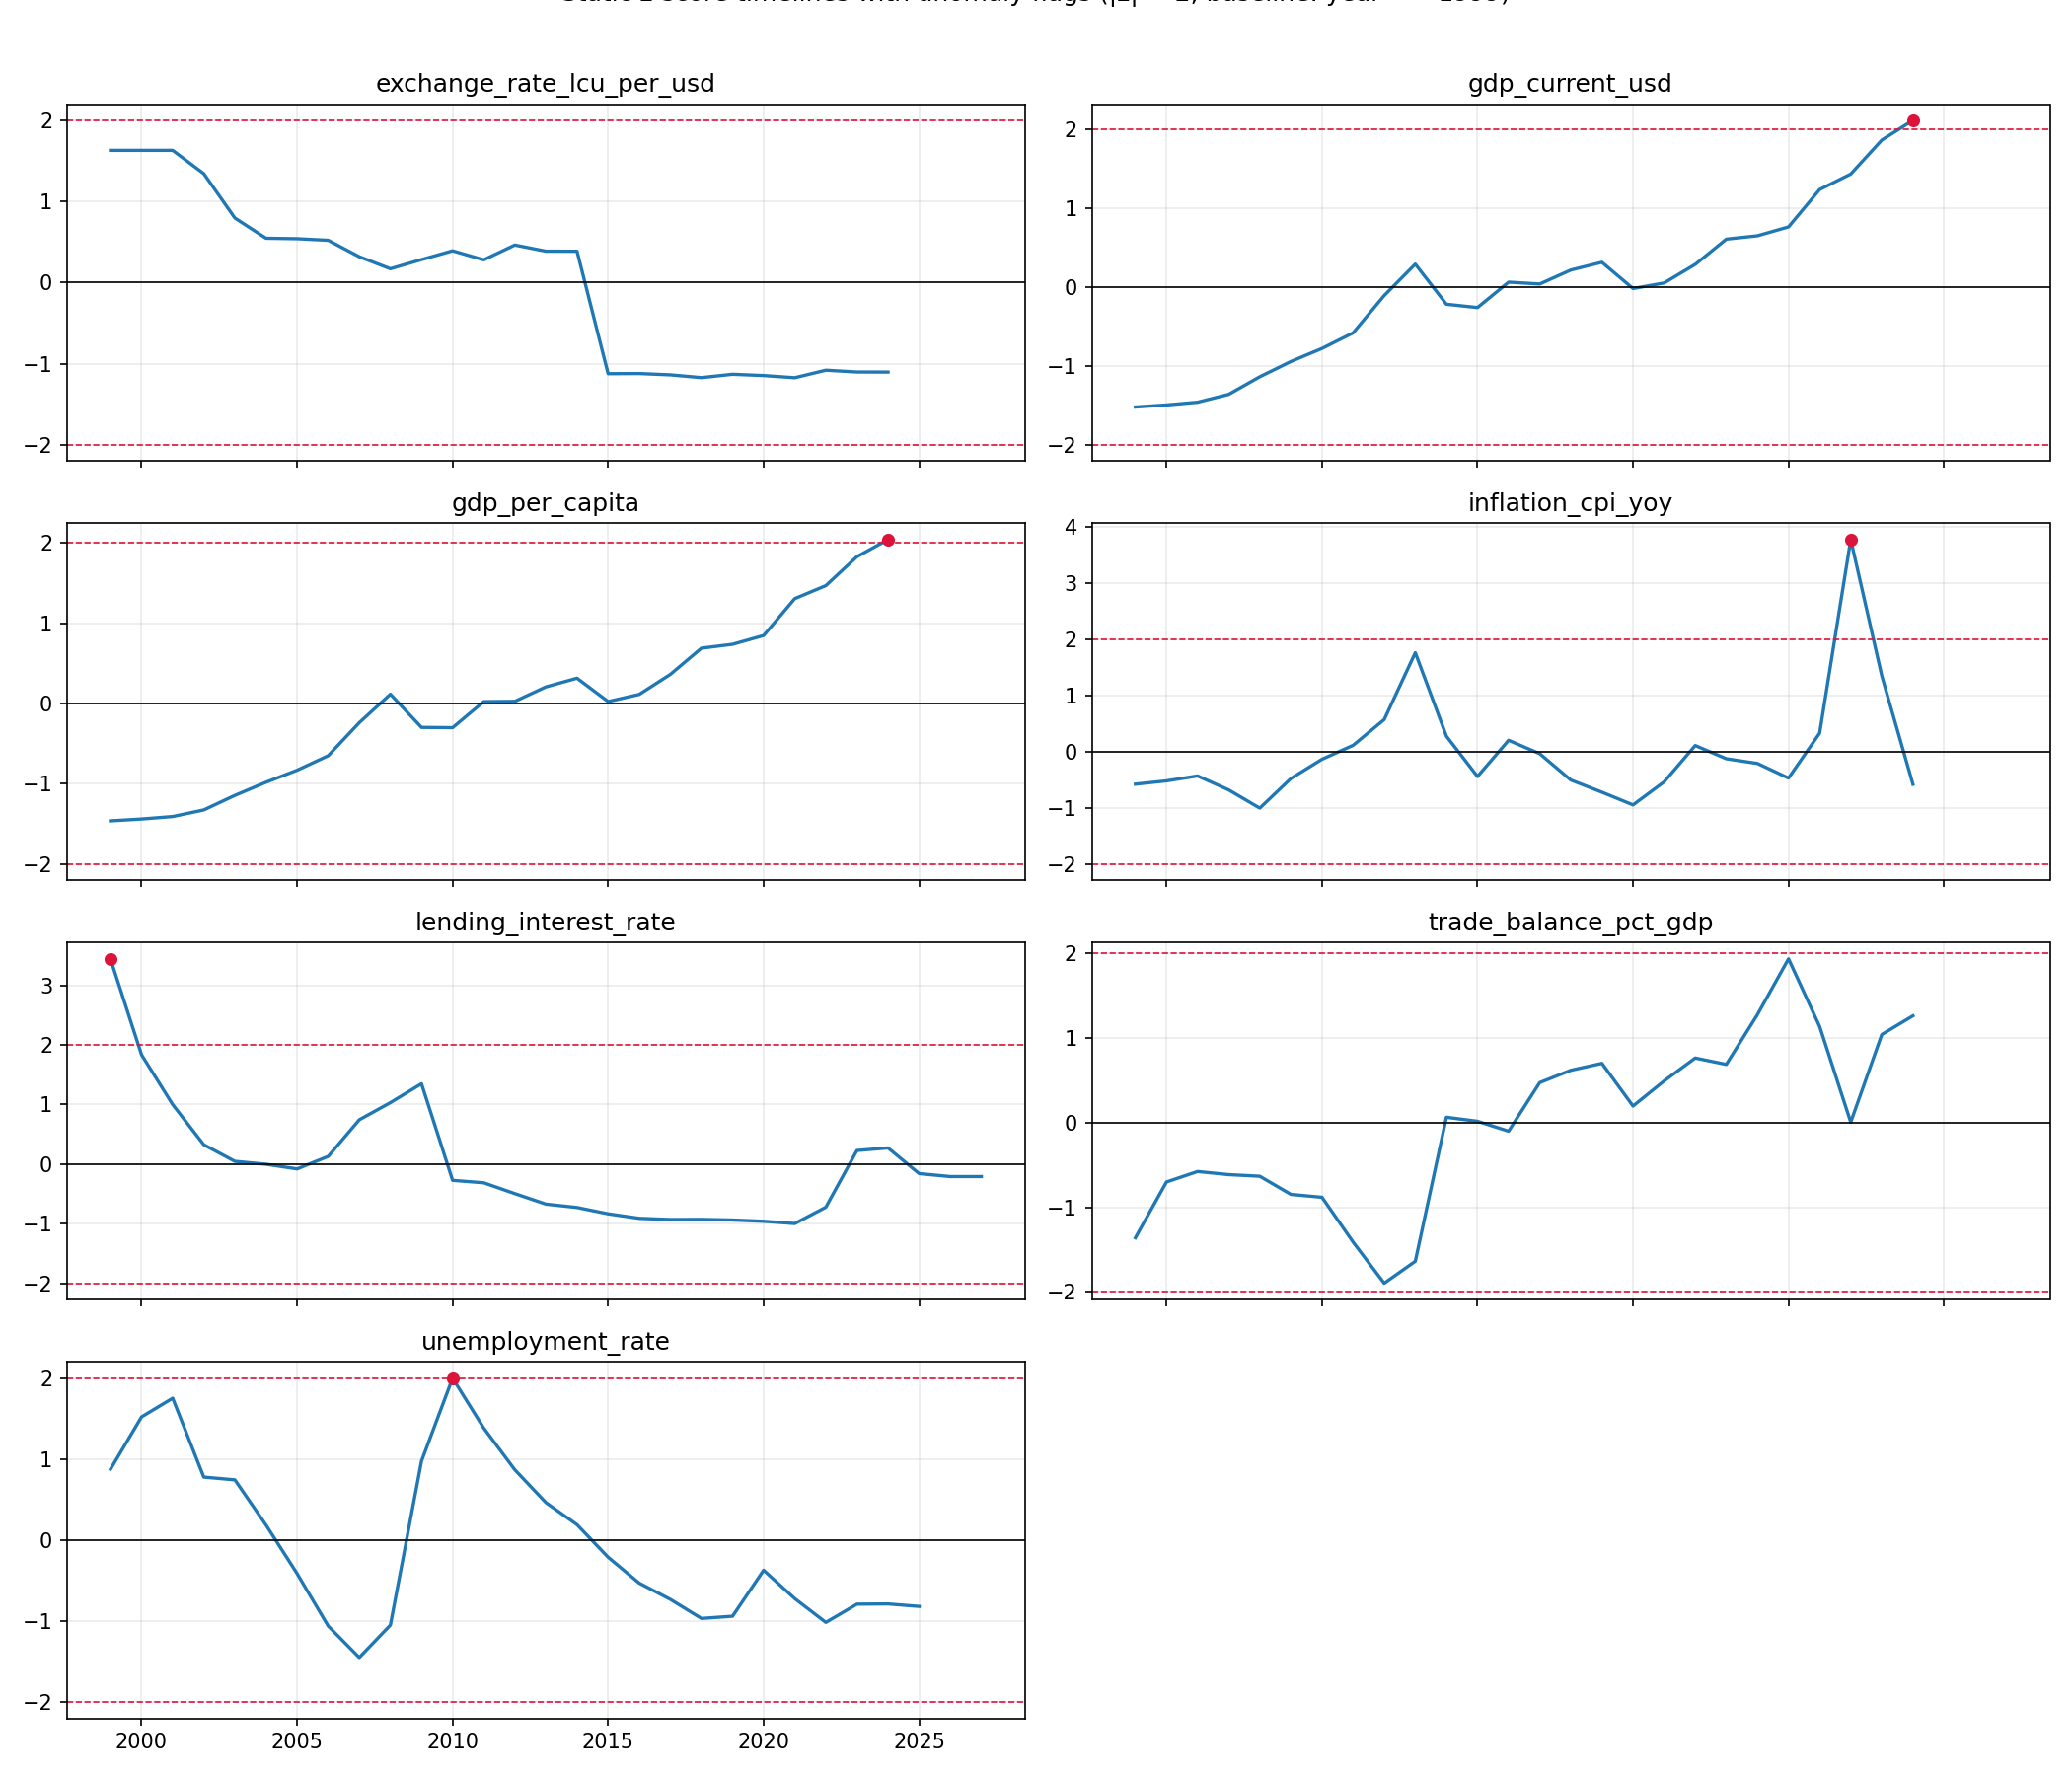

In [14]:
from IPython.display import Image, Markdown, display

heatmap_path = outdir / 'charts' / 'zscore_normalization_heatmap.png'
timeline_path = outdir / 'charts' / 'zscore_normalization_timelines.png'

display(Markdown('## Static z-score visuals'))
display(Image(filename=str(heatmap_path)))
display(Image(filename=str(timeline_path)))


![GDP harmonized values by source](outputs/charts/gdp_current_usd_raw_harmonized.png)

*Figure: GDP harmonized values by source.*

In [12]:
%%latex
"As shown in Figure \ref{fig:gdp_harmonized}, GDP trends diverge after 2020."



<IPython.core.display.Latex object>

In [13]:
%%latex
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{outputs/charts/gdp_current_usd_raw_harmonized.png}
\caption{GDP harmonized values by source}
\label{fig:gdp_harmonized}
\end{figure}

<IPython.core.display.Latex object>